# Week 7 Feature Engineering
> by Lei Ding, Updated Mar. 2025

In [1]:
# 准备
#install.packages('titanic')
#install.packages('ggbiplot')
#install.packages('mlbench')
#install.packages('caret')
#install.packages('randomForest')
#install.packages('corrplot')

## 1. 不同的特征类型

In [2]:
library(titanic)
data(titanic_train)  # 加载数据集
head(titanic_train)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q


## 2. 主成分分析

In [3]:
# PCA的计算示例：iris数据集
iris_scale <- scale(iris[-5])
iris_cor <- cov(iris_scale)  # covariance
ev <- eigen(iris_cor)
pca_iris <- ev$vectors  # Eigen vectors
colnames(pca_iris) <- c('pc1', 'pc2', 'pc3', 'pc4')
pca_r <- prcomp(iris[-5], center=TRUE, scale.=TRUE)$rotation
print(head(cbind(pca_iris, pca_r)))

                    pc1         pc2        pc3        pc4        PC1
Sepal.Length  0.5210659 -0.37741762  0.7195664  0.2612863  0.5210659
Sepal.Width  -0.2693474 -0.92329566 -0.2443818 -0.1235096 -0.2693474
Petal.Length  0.5804131 -0.02449161 -0.1421264 -0.8014492  0.5804131
Petal.Width   0.5648565 -0.06694199 -0.6342727  0.5235971  0.5648565
                     PC2        PC3        PC4
Sepal.Length -0.37741762  0.7195664  0.2612863
Sepal.Width  -0.92329566 -0.2443818 -0.1235096
Petal.Length -0.02449161 -0.1421264 -0.8014492
Petal.Width  -0.06694199 -0.6342727  0.5235971


In [4]:
# mtcars主成分分析
mtcars.pca <- prcomp(mtcars[, c(1:7, 10, 11)], center=TRUE, scale.=TRUE)
summary(mtcars.pca)

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     2.3782 1.4429 0.71008 0.51481 0.42797 0.35184 0.32413
Proportion of Variance 0.6284 0.2313 0.05602 0.02945 0.02035 0.01375 0.01167
Cumulative Proportion  0.6284 0.8598 0.91581 0.94525 0.96560 0.97936 0.99103
                          PC8     PC9
Standard deviation     0.2419 0.14896
Proportion of Variance 0.0065 0.00247
Cumulative Proportion  0.9975 1.00000

In [5]:
str(mtcars.pca)

List of 5
 $ sdev    : num [1:9] 2.378 1.443 0.71 0.515 0.428 ...
 $ rotation: num [1:9, 1:9] -0.393 0.403 0.397 0.367 -0.312 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:9] "mpg" "cyl" "disp" "hp" ...
  .. ..$ : chr [1:9] "PC1" "PC2" "PC3" "PC4" ...
 $ center  : Named num [1:9] 20.09 6.19 230.72 146.69 3.6 ...
  ..- attr(*, "names")= chr [1:9] "mpg" "cyl" "disp" "hp" ...
 $ scale   : Named num [1:9] 6.027 1.786 123.939 68.563 0.535 ...
  ..- attr(*, "names")= chr [1:9] "mpg" "cyl" "disp" "hp" ...
 $ x       : num [1:32, 1:9] -0.664 -0.637 -2.3 -0.215 1.587 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:32] "Mazda RX4" "Mazda RX4 Wag" "Datsun 710" "Hornet 4 Drive" ...
  .. ..$ : chr [1:9] "PC1" "PC2" "PC3" "PC4" ...
 - attr(*, "class")= chr "prcomp"


In [6]:
mtcars.pca$x

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Mazda RX4,-0.66422351,1.1734476,-0.20431724,-0.12601751,0.75200784,-0.12506777,0.42357334,0.003259165,-0.167051112
Mazda RX4 Wag,-0.63719807,0.9769448,0.11077779,-0.08567709,0.65668822,-0.06619437,0.44849307,-0.056643244,-0.071592094
Datsun 710,-2.29973601,-0.3265893,-0.21014955,-0.10862524,-0.07622329,-0.56693648,-0.38612406,0.202035744,0.114505030
Hornet 4 Drive,-0.21529670,-1.9768101,-0.32946822,-0.30806225,-0.24391787,0.08382435,-0.03299362,0.023714111,-0.145255757
Hornet Sportabout,1.58697405,-0.8287285,-1.03299254,0.14738418,-0.22270405,0.18280435,0.05793795,-0.152342587,-0.154646072
Valiant,0.04960512,-2.4466838,0.11177774,-0.87154914,-0.12574876,-0.23043022,-0.22451528,-0.098663134,-0.004233901
Duster 360,2.71439677,0.3610529,-0.65206041,0.09633337,0.29674234,0.27763557,-0.44227307,0.306373481,-0.186980810
Merc 240D,-2.04370658,-0.8006412,0.84898795,-0.27451338,-0.26307848,-0.19042527,0.39416400,0.187088365,-0.010461330
Merc 230,-2.29506729,-1.3056004,1.96848450,0.05055875,-0.45988113,0.20443847,-0.53713423,-0.413455512,-0.169005773
Merc 280,-0.38252133,0.5811211,0.88632274,0.07026946,0.45835852,-0.07984989,0.26113412,-0.204105964,0.110461785


Loading required package: ggplot2



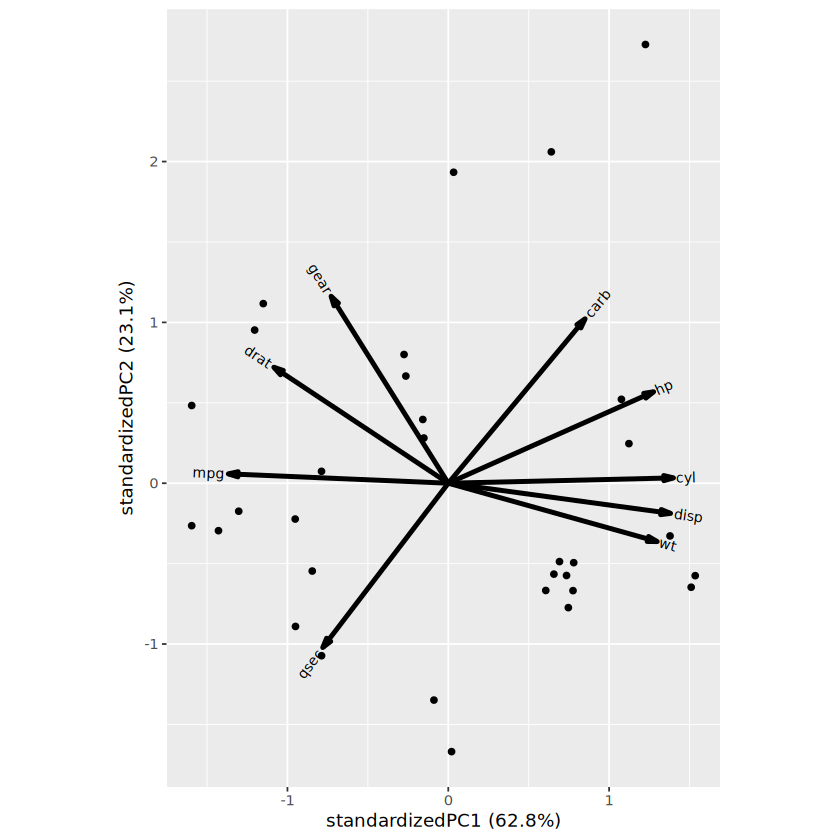

In [7]:
library(ggbiplot)
ggbiplot(mtcars.pca)

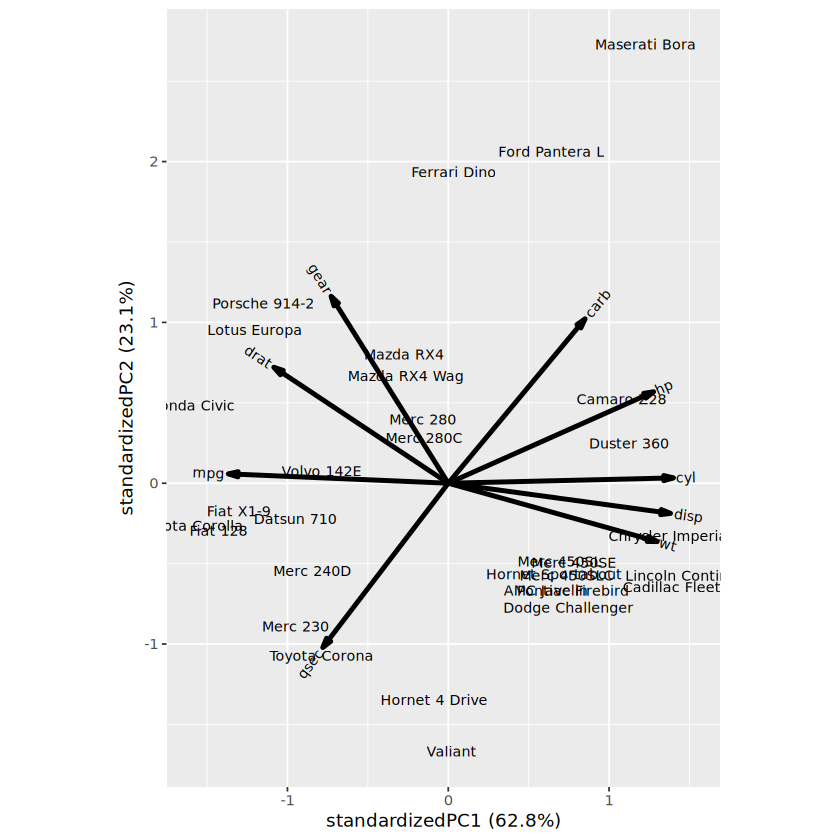

In [8]:
ggbiplot(mtcars.pca, labels=rownames(mtcars))

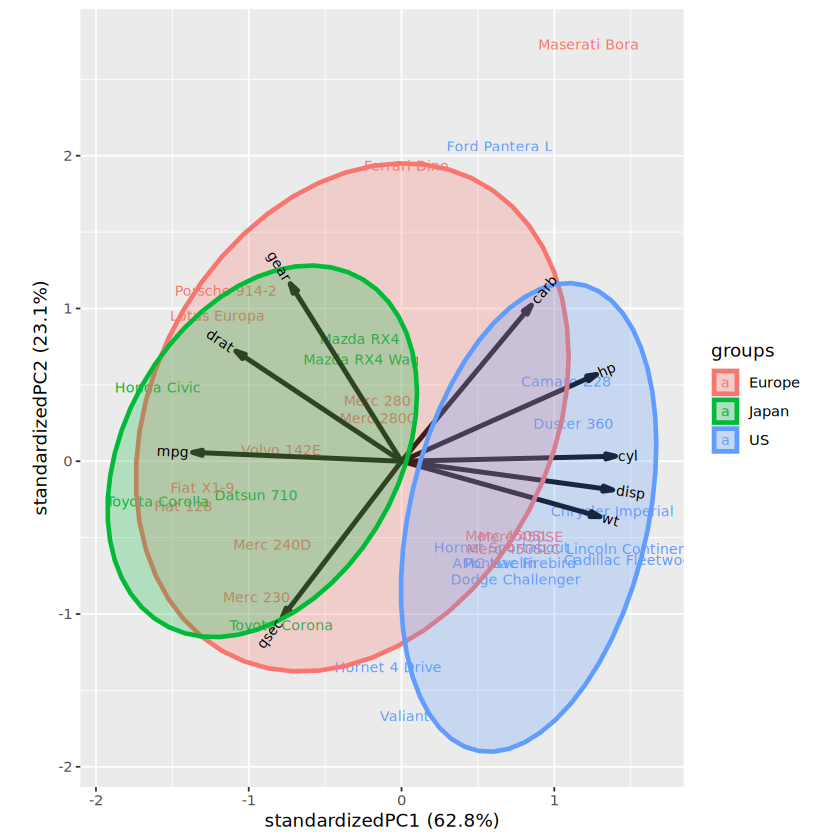

In [9]:
mtcars.country <- c(rep('Japan', 3), rep('US', 4), rep('Europe', 7), 
                    rep('US', 3), 'Europe', rep('Japan', 3), rep('US', 4), 
                    rep('Europe', 3), 'US', rep('Europe', 3))
ggbiplot(mtcars.pca, ellipse=TRUE, labels=rownames(mtcars), groups=mtcars.country)

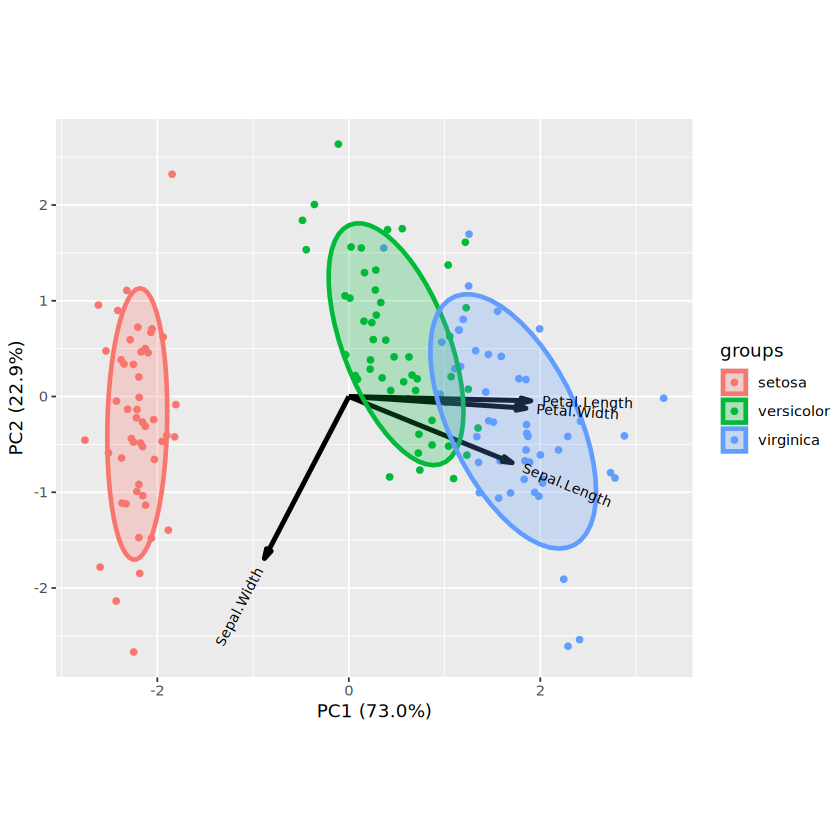

In [10]:
# iris主成分分析
iris.pca <- prcomp(iris[, 1:4], scale=TRUE)
ggbiplot(iris.pca, obs.scale=1, var.scale=1, groups=iris[, 5], ellipse=TRUE, ellips.prob=0.8)

# 3. 特征子集选择

In [11]:
library(ggplot2)
head(diamonds)

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


In [12]:
library(mlbench)
data(PimaIndiansDiabetes)
head(PimaIndiansDiabetes)

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,6,148,72,35,0,33.6,0.627,50,pos
2,1,85,66,29,0,26.6,0.351,31,neg
3,8,183,64,0,0,23.3,0.672,32,pos
4,1,89,66,23,94,28.1,0.167,21,neg
5,0,137,40,35,168,43.1,2.288,33,pos
6,5,116,74,0,0,25.6,0.201,30,neg


In [13]:
correlationMatrix <- cor(PimaIndiansDiabetes[, 1:8])
correlationMatrix

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age
pregnant,1.00000000,0.12945867,0.14128198,-0.08167177,-0.07353461,0.01768309,-0.03352267,0.54434123
glucose,0.12945867,1.00000000,0.15258959,0.05732789,0.33135711,0.22107107,0.13733730,0.26351432
pressure,0.14128198,0.15258959,1.00000000,0.20737054,0.08893338,0.28180529,0.04126495,0.23952795
triceps,-0.08167177,0.05732789,0.20737054,1.00000000,0.43678257,0.39257320,0.18392757,-0.11397026
insulin,-0.07353461,0.33135711,0.08893338,0.43678257,1.00000000,0.19785906,0.18507093,-0.04216295
mass,0.01768309,0.22107107,0.28180529,0.39257320,0.19785906,1.00000000,0.14064695,0.03624187
pedigree,-0.03352267,0.13733730,0.04126495,0.18392757,0.18507093,0.14064695,1.00000000,0.03356131
age,0.54434123,0.26351432,0.23952795,-0.11397026,-0.04216295,0.03624187,0.03356131,1.00000000


In [14]:
library(caret)
highlyCorrelated <- findCorrelation(correlationMatrix, cutoff=0.5, names=TRUE)
highlyCorrelated

Loading required package: lattice



[1] "age"

In [15]:
highlyCorrelated <- findCorrelation(correlationMatrix, cutoff=0.3, names=TRUE)
highlyCorrelated

[1] "triceps" "insulin" "age"

corrplot 0.95 loaded



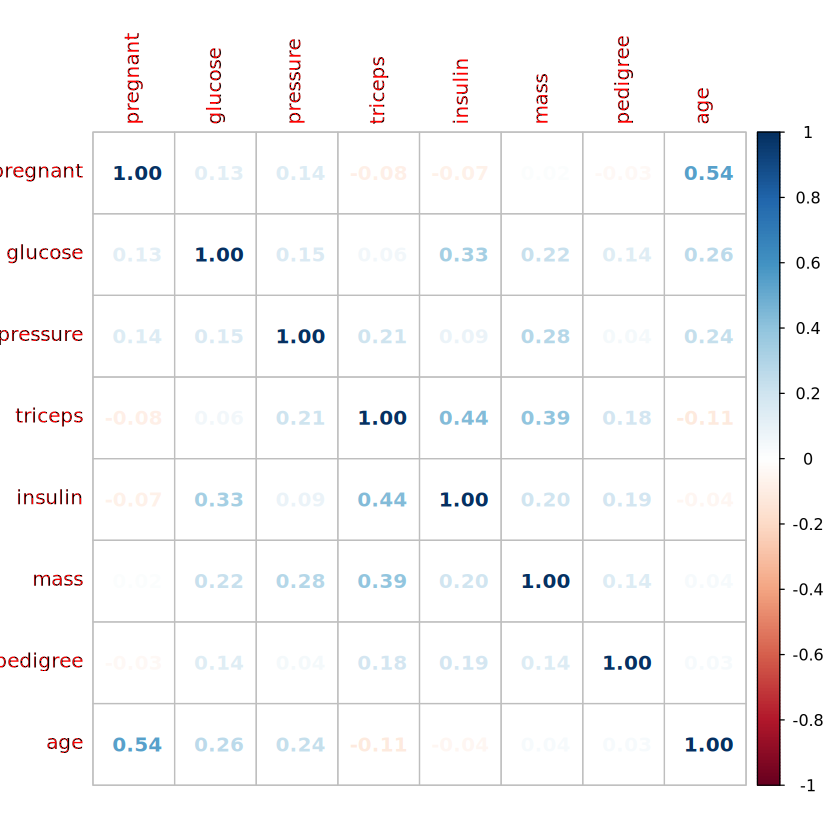

In [16]:
library(corrplot)
corrplot(correlationMatrix, method="number")

In [17]:
library(caret)
library(randomForest)
control <- rfeControl(functions=rfFuncs, method="cv", number=10)
results <- rfe(PimaIndiansDiabetes[, 1:8], PimaIndiansDiabetes[, 9], sizes=c(1:8), rfeControl=control)
results

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin





Recursive feature selection

Outer resampling method: Cross-Validated (10 fold) 

Resampling performance over subset size:

 Variables Accuracy  Kappa AccuracySD KappaSD Selected
         1   0.7031 0.2813    0.04535 0.11832         
         2   0.7357 0.3982    0.04177 0.10492         
         3   0.7409 0.4161    0.02297 0.06024         
         4   0.7526 0.4435    0.02588 0.06053         
         5   0.7448 0.4202    0.01934 0.05335         
         6   0.7514 0.4323    0.03307 0.07694         
         7   0.7527 0.4395    0.02136 0.05465         
         8   0.7735 0.4835    0.02966 0.06738        *

The top 5 variables (out of 8):
   glucose, mass, age, pregnant, pedigree


In [18]:
predictors(results)

[1] "glucose"  "mass"     "age"      "pregnant" "pedigree" "insulin"  "triceps" 
[8] "pressure"

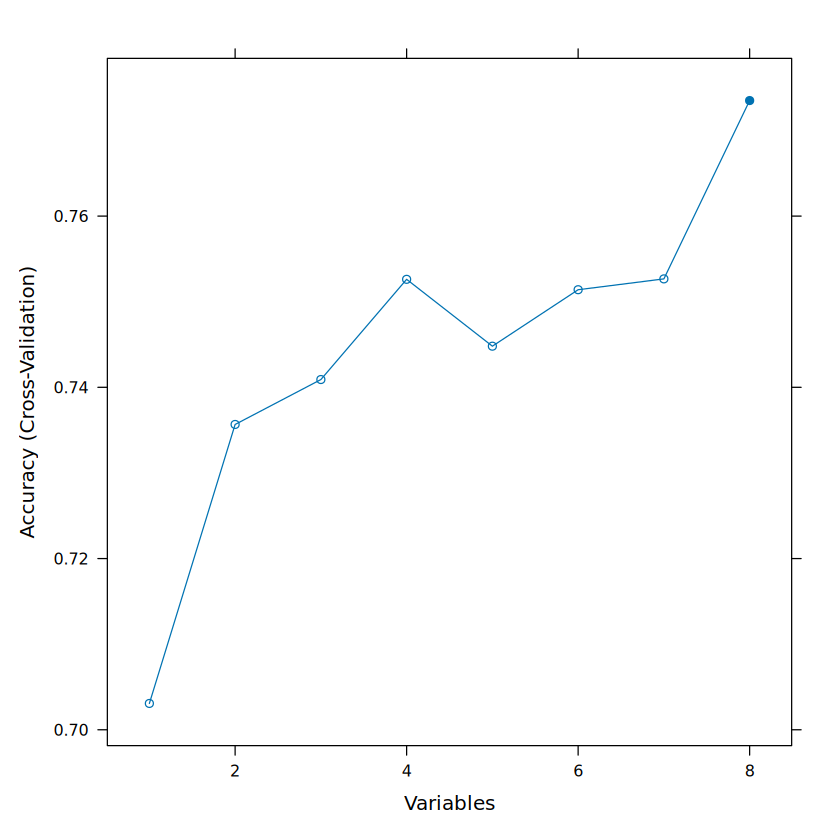

In [19]:
plot(results, type='o')